In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
df = iris.frame
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))

df.head()


#Converting numeric labels to human-readable categories makes grouping, visualization, and interpretation clearer and reduces the risk of misinterpretation.

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [7]:
#Descriptive Statistics

sepal_stats = df.groupby('species')['sepal length (cm)'].agg(
    mean='mean',
    median='median',
    std='std'
)

sepal_stats

highest_variability = sepal_stats['std'].idxmax()
highest_variability

#Virginica shows the highest variability in sepal length,indicating greater spread in measurements compared to other species.



np.str_('virginica')

In [8]:
#Central Tendency & Dispersion (Petal Length)

petal_stats = df.groupby('species')['petal length (cm)'].agg(
    mean='mean',
    median='median',
    variance='var',
    std='std'
)

petal_stats

modes = df.groupby('species')['petal length (cm)'].apply(
    lambda x: stats.mode(x, keepdims=True).mode[0]
)
modes


,petal length (cm)
species,
setosa,1.4
versicolor,4.5
virginica,5.1


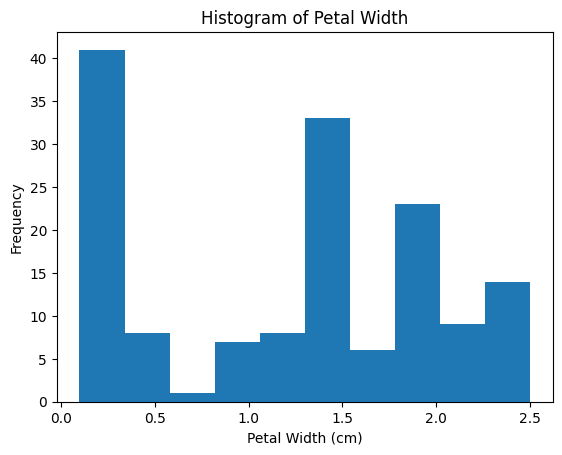

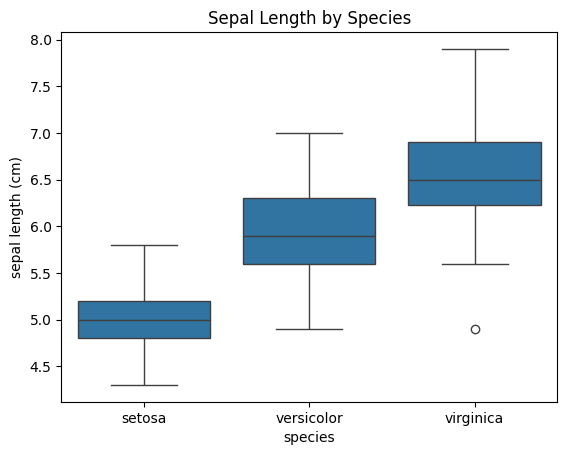

In [9]:
#Visualization

plt.hist(df['petal width (cm)'])
plt.title("Histogram of Petal Width")
plt.xlabel("Petal Width (cm)")
plt.ylabel("Frequency")
plt.show()


sns.boxplot(x='species', y='sepal length (cm)', data=df)
plt.title("Sepal Length by Species")
plt.show()


#The boxplot better shows between-species differences because it clearly displays medians, spread, and outliers for each species.



In [10]:
#Distributions & Skewness (Petal Length)

skewness = df.groupby('species')['petal length (cm)'].apply(stats.skew)
skewness


most_positive = skewness.idxmax()
most_negative = skewness.idxmin()

most_positive, most_negative

#Setosa is the most positively skewed, while Virginica shows the most negative skewness.
#This indicates differences in distribution shape across species.

(np.str_('virginica'), np.str_('versicolor'))

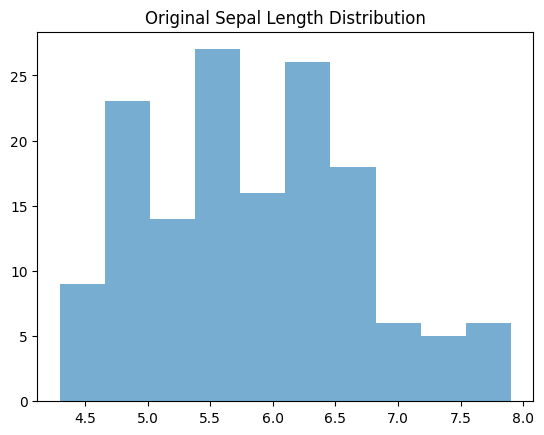

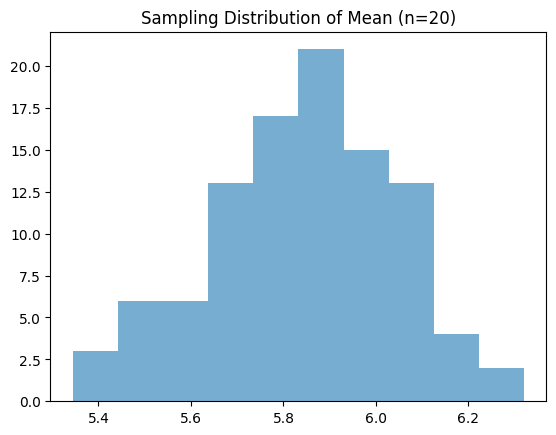

In [11]:
#Sampling & Central Limit Theorem

np.random.seed(42)

sepal_length = df['sepal length (cm)']
sample_means = []

for _ in range(100):
    sample = np.random.choice(sepal_length, size=20, replace=True)
    sample_means.append(sample.mean())


plt.hist(sepal_length, alpha=0.6)
plt.title("Original Sepal Length Distribution")
plt.show()

plt.hist(sample_means, alpha=0.6)
plt.title("Sampling Distribution of Mean (n=20)")
plt.show()


#The sampling distribution of the mean is more symmetric and concentrated around the mean, illustrating the Central Limit Theorem.

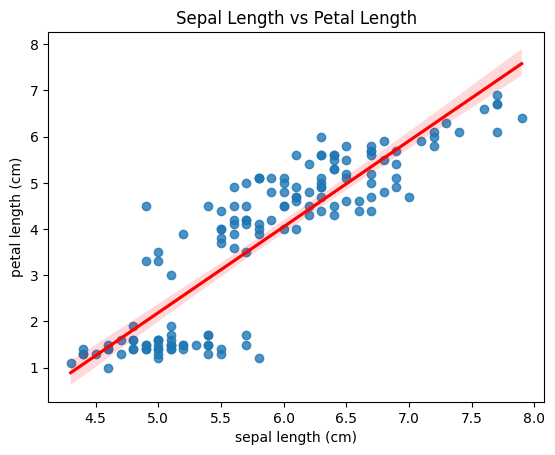

In [12]:
#Correlation (Sepal Length vs Petal Length)

r, p = stats.pearsonr(df['sepal length (cm)'], df['petal length (cm)'])
r, p


sns.regplot(
    x='sepal length (cm)',
    y='petal length (cm)',
    data=df,
    line_kws={"color": "red"}
)
plt.title("Sepal Length vs Petal Length")
plt.show()


#The relationship is positive, meaning longer sepals are associated with longer petals.

In [13]:
#Hypothesis Testing: t-Test (2 Groups)

setosa = df[df['species'] == 'setosa']['petal length (cm)']
versicolor = df[df['species'] == 'versicolor']['petal length (cm)']

t_stat, p_value = stats.ttest_ind(setosa, versicolor)
t_stat, p_value

#The p-value is below 0.05, so we reject the null hypothesis and conclude that the mean petal length differs between Set

(np.float64(-39.492719391538095), np.float64(5.404910513441677e-62))

In [14]:
#Hypothesis Testing: ANOVA (3 Groups)

virginica = df[df['species'] == 'virginica']['petal width (cm)']

f_stat, p_value = stats.f_oneway(setosa, versicolor, virginica)
f_stat, p_value

#The ANOVA test shows a significant difference in petal width among the three species.


(np.float64(1006.2291234212867), np.float64(1.672940395623648e-86))